#  Group4 Ninapro-db1 Dataset EDA

# Load data

In [23]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/mansibmursalin/ninapro-db1-full-dataset/Ninapro_DB1.csv"
)
df = df.drop(columns=['Unnamed: 0'])
df.shape

(12553611, 38)

# Basic structure check

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12553611 entries, 0 to 12553610
Data columns (total 38 columns):
 #   Column        Dtype  
---  ------        -----  
 0   emg_0         float64
 1   emg_1         float64
 2   emg_2         float64
 3   emg_3         float64
 4   emg_4         float64
 5   emg_5         float64
 6   emg_6         float64
 7   emg_7         float64
 8   emg_8         float64
 9   emg_9         float64
 10  glove_0       float64
 11  glove_1       float64
 12  glove_2       float64
 13  glove_3       float64
 14  glove_4       float64
 15  glove_5       float64
 16  glove_6       float64
 17  glove_7       float64
 18  glove_8       float64
 19  glove_9       float64
 20  glove_10      float64
 21  glove_11      float64
 22  glove_12      float64
 23  glove_13      float64
 24  glove_14      float64
 25  glove_15      float64
 26  glove_16      float64
 27  glove_17      float64
 28  glove_18      float64
 29  glove_19      float64
 30  glove_20      fl

# Setup: imports + column groups

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px

sns.set(style="whitegrid")

emg_columns = [c for c in df.columns if c.startswith('emg_')]
glove_columns = [c for c in df.columns if c.startswith('glove_')]
rep_col = 'repetition' if 'repetition' in df.columns else ('rerepetition' if 'rerepetition' in df.columns else None)

print("EMG channels:", emg_columns)
print("Glove sensors:", len(glove_columns))
print("Repetition column found:", rep_col)

EMG channels: ['emg_0', 'emg_1', 'emg_2', 'emg_3', 'emg_4', 'emg_5', 'emg_6', 'emg_7', 'emg_8', 'emg_9']
Glove sensors: 22
Repetition column found: repetition


# A-Dataset summary table

In [26]:
summary = pd.DataFrame([{
    "Dataset": "NinaPro DB1",
    "Source": "ninapro.hevs.ch (via Kaggle: mansibmursalin/ninapro-db1-full-dataset)",
    "Area": "EMG gesture recognition",
    "Total rows (raw timepoints)": len(df),
    "Subjects": df['subject'].nunique(),
    "EMG channels": len(emg_columns),
    "Glove sensors": len(glove_columns),
    "Exercises": df['exercise'].nunique(),
    "Gesture classes (restimulus)": df['restimulus'].nunique(),
    "Missing values (total)": int(df.isnull().sum().sum()),
    "Duplicate rows": int(df.duplicated().sum()),
}])
summary.T

,0
Dataset,NinaPro DB1
Source,ninapro.hevs.ch (via Kaggle: mansibmursalin/ni...
Area,EMG gesture recognition
Total rows (raw timepoints),12553611
Subjects,27
EMG channels,10
Glove sensors,22
Exercises,3
Gesture classes (restimulus),24
Missing values (total),0


In [27]:
counts = df['restimulus'].value_counts()
print(f"Majority class count: {counts.max()}  |  Minority class count: {counts.min()}")
print(f"Majority:minority ratio = {counts.max()/counts.min():.1f}")

Majority class count: 7290845  |  Minority class count: 106193
Majority:minority ratio = 68.7


 **(A — Summary):** The dataset has 27 subjects, 10 EMG channels, and 24 gesture
classes (restimulus). Missing values: 0. Duplicate rows: 224801.
Majority: minority class ratio is 68.7.

# Windowing — build the feature table used for B, C, E, F, G

In [28]:
WIN_LEN, STEP = 200, 100  

def extract_features(window_emg):
    feats = {}
    for i, col in enumerate(emg_columns):
        sig = window_emg[:, i]
        feats[f"{col}_RMS"] = np.sqrt(np.mean(sig**2))
        feats[f"{col}_MAV"] = np.mean(np.abs(sig))
        feats[f"{col}_WL"]  = np.sum(np.abs(np.diff(sig)))
        feats[f"{col}_VAR"] = np.var(sig)
        feats[f"{col}_ZC"]  = np.sum(np.diff(np.sign(sig)) != 0)
        feats[f"{col}_SSC"] = np.sum(np.diff(np.sign(np.diff(sig))) != 0)
    return feats

feature_rows = []
group_cols = ['subject', 'exercise', rep_col, 'restimulus'] if rep_col else ['subject', 'exercise', 'restimulus']

eda_subjects = sorted(df['subject'].unique())[:5]  
df_sub = df[df['subject'].isin(eda_subjects)]

for keys, g in df_sub.groupby(group_cols):
    emg_vals = g[emg_columns].values
    for start in range(0, len(emg_vals) - WIN_LEN, STEP):
        window = emg_vals[start:start+WIN_LEN]
        f = extract_features(window)
        f['label'] = g['restimulus'].iloc[0]
        f['subject'] = g['subject'].iloc[0]
        feature_rows.append(f)

feat_df = pd.DataFrame(feature_rows)
print(feat_df.shape)
feat_df.head()

(18904, 62)


,emg_0_RMS,emg_0_MAV,emg_0_WL,emg_0_VAR,emg_0_ZC,emg_0_SSC,emg_1_RMS,emg_1_MAV,emg_1_WL,emg_1_VAR,...,emg_8_ZC,emg_8_SSC,emg_9_RMS,emg_9_MAV,emg_9_WL,emg_9_VAR,emg_9_ZC,emg_9_SSC,label,subject
0,0.037169,0.035133,1.0159,0.000147,0,80,0.002438,0.002425,0.010,6.187500e-08,...,0,0,0.004756,0.003074,0.0468,1.316780e-05,0,12,0,1
1,0.029822,0.027538,0.9479,0.000131,0,79,0.002419,0.002412,0.005,3.109375e-08,...,0,0,0.002789,0.002610,0.0348,9.621398e-07,0,20,0,1
2,0.025360,0.022920,0.8922,0.000118,0,82,0.002419,0.002412,0.005,3.109375e-08,...,0,0,0.003148,0.002845,0.0669,1.811980e-06,0,33,0,1
3,0.027127,0.024594,0.8308,0.000131,0,87,0.002438,0.002425,0.010,6.187500e-08,...,0,3,0.002825,0.002647,0.0396,9.739938e-07,0,18,0,1
4,0.033752,0.031119,0.8914,0.000171,0,86,0.002419,0.002412,0.005,3.109375e-08,...,0,3,0.002475,0.002450,0.0200,1.225000e-07,0,11,0,1


# B — Descriptive statistics

In [29]:
feature_cols = [c for c in feat_df.columns if c not in ['label', 'subject']]

desc = feat_df[feature_cols].describe().T
desc["skew"] = feat_df[feature_cols].skew()
desc["kurtosis"] = feat_df[feature_cols].kurt()
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
emg_0_RMS,18904.0,0.206903,0.379864,2.400000e-03,3.844104e-03,4.147873e-02,0.208486,3.553799,2.884333,9.684315
emg_0_MAV,18904.0,0.183295,0.349061,2.400000e-03,3.214000e-03,2.993350e-02,0.179057,3.406358,2.940431,9.917451
emg_0_WL,18904.0,2.212569,3.158542,0.000000e+00,1.038000e-01,8.512500e-01,2.896225,21.071900,2.157864,4.885334
emg_0_VAR,18904.0,0.031663,0.125976,0.000000e+00,4.332097e-06,5.899436e-04,0.008852,2.769621,9.970186,139.982848
emg_0_ZC,18904.0,0.000106,0.014546,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2.000000,137.491818,18904.000000
emg_0_SSC,18904.0,59.444033,24.266492,0.000000e+00,4.100000e+01,6.400000e+01,77.000000,122.000000,-0.352762,-0.604132
emg_1_RMS,18904.0,0.196125,0.307135,2.393992e-03,2.437724e-03,5.987972e-02,0.274187,3.311119,2.989429,13.616621
emg_1_MAV,18904.0,0.168072,0.270357,2.388000e-03,2.425000e-03,3.774450e-02,0.235224,3.093640,3.018675,14.378877
emg_1_WL,18904.0,2.407134,2.961770,0.000000e+00,1.000000e-02,1.177250e+00,4.130525,23.234800,1.533736,2.874455
emg_1_VAR,18904.0,0.031455,0.128471,0.000000e+00,6.187500e-08,1.532000e-03,0.015323,3.294757,10.568950,157.250722


**(B — Statistics):** RMS/MAV features across all 10 channels are strongly
right-skewed (skew ≈ 2.9–14, kurtosis up to ~260 for emg_4_MAV), meaning most windows sit
near a low baseline with occasional large-amplitude bursts — consistent with rest periods
dominating and gesture contractions appearing as sparse spikes. VAR is even more
heavy-tailed (kurtosis up to ~644 for emg_4_VAR), so a few high-activity windows are driving
most of the variance. ZC is degenerate for channels 2, 4, and 7 (std = 0, skew = 0,
kurtosis = 0 — the value is constant at zero for every window) and near-constant for
channels 0, 3, 6, 9 (extremely high kurtosis with std close to zero), so ZC is unlikely to
be a useful feature for this dataset and is a candidate for removal in Task 2 preprocessing.
SSC is the best-behaved feature (skew close to 0, mildly negative kurtosis meaning a
flatter-than-normal spread), so it may carry the most linearly usable signal on its own.
Mean amplitude also varies noticeably by channel — channels 0, 1, 2, 6, 7 show visibly
higher RMS/MAV means than channels 3, 4, 5 — suggesting these electrodes sit over more
active muscle groups for the gestures in this dataset.

# C — Data quality

In [30]:
print("Missing values:", feat_df[feature_cols].isna().sum().sum())
print("Duplicate rows:", feat_df.duplicated().sum())

near_constant = [c for c in feature_cols if feat_df[c].std() < 1e-6]
print("Near-constant features:", near_constant)

corr = feat_df[feature_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
redundant = [col for col in upper.columns if any(upper[col] > 0.95)]
print("Highly correlated (>0.95) features:", redundant)

z = np.abs(stats.zscore(feat_df[feature_cols]))
outlier_pct = (z > 3).mean(axis=0) * 100
pd.Series(outlier_pct, index=feature_cols).sort_values(ascending=False).head(10)

Missing values: 0
Duplicate rows: 0
Near-constant features: ['emg_2_ZC', 'emg_4_ZC', 'emg_7_ZC']
Highly correlated (>0.95) features: ['emg_0_MAV', 'emg_1_MAV', 'emg_2_MAV', 'emg_2_WL', 'emg_3_MAV', 'emg_3_WL', 'emg_4_MAV', 'emg_5_MAV', 'emg_6_MAV', 'emg_7_MAV', 'emg_7_WL', 'emg_8_MAV', 'emg_9_MAV']


emg_0_MAV    2.999365
emg_0_RMS    2.888278
emg_8_WL     2.697842
emg_8_MAV    2.618493
emg_8_RMS    2.613204
emg_6_WL     2.475667
emg_7_WL     2.475667
emg_5_RMS    2.470377
emg_5_MAV    2.449217
emg_6_RMS    2.438637
dtype: float64

**(C — Data quality):** No missing values and no duplicate rows, so the windowing
step didn't introduce redundant or corrupted samples. Three features — emg_2_ZC, emg_4_ZC,
emg_7_ZC — are near-constant (std < 1e-6), confirming what the Part B statistics already
showed (these same channels had zero skew/kurtosis for ZC): zero-crossing counts are
essentially uninformative for this dataset and are candidates for removal before modeling.
13 features are highly correlated (>0.95) with at least one other feature, and the pattern
is consistent: MAV is redundant with RMS for almost every channel (both measure signal
amplitude, so this is expected), and WL is redundant with MAV/RMS specifically for channels
2, 3, and 7. This means our 6 features-per-channel are not all independent — for
GNN node-feature design in Task 2, we can likely drop MAV in favor of RMS without losing
information, and treat WL as redundant on the channels flagged here. Outliers (z > 3) are
concentrated in the RMS/MAV/WL family (2.4–3.0% of windows for the top channels), which
lines up with the heavy right-skew seen in Part B — these are genuine high-activity
contraction windows, not sensor artifacts, so they should be kept rather than clipped.

# D — Class balance

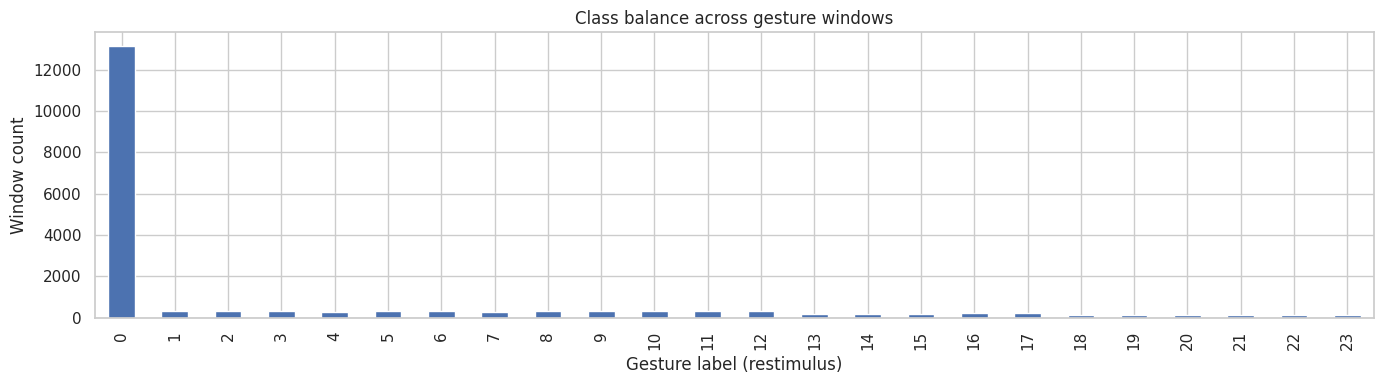

In [31]:
fig, ax = plt.subplots(figsize=(14, 4))
feat_df['label'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel("Gesture label (restimulus)")
ax.set_ylabel("Window count")
ax.set_title("Class balance across gesture windows")
plt.tight_layout(); plt.show()

**(D — Class balance):** Class 0 (rest) massively dominates the dataset at over
13,000 windows, while every gesture class (1–23) sits in a narrow band of roughly 150–400
windows each. This is an extreme imbalance — rest outnumbers any individual gesture by
roughly 30–80×. Reporting raw accuracy on this data would be misleading, since a model
that only ever predicts "rest" would still score deceptively high; per §6.2 we will use
macro-F1 and per-class recall as the primary metrics, and will likely need class weighting,
targeted resampling, or excluding/down-weighting rest windows in the training pipeline for
both the baselines and the GNN in Task 2.

# E — Feature distributions

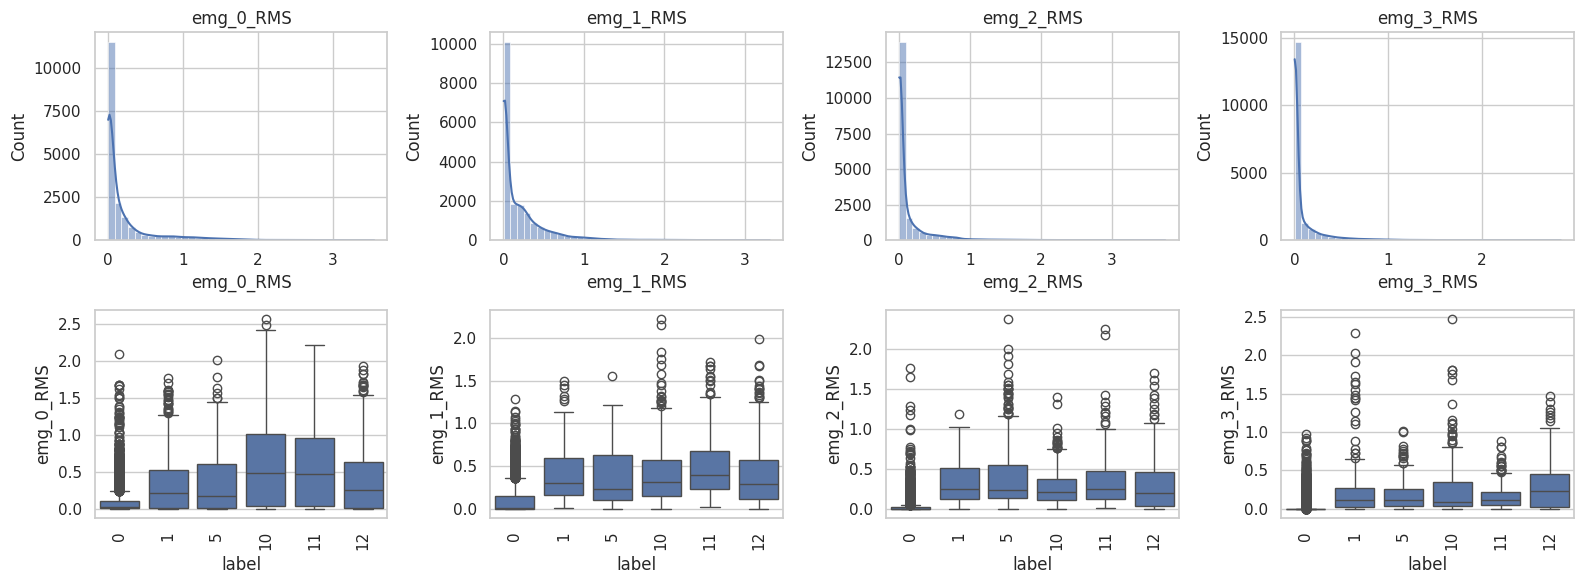

In [32]:
sample_feats = [c for c in feature_cols if "RMS" in c][:4]

fig, axes = plt.subplots(2, len(sample_feats), figsize=(16, 6))
for i, f in enumerate(sample_feats):
    sns.histplot(feat_df[f], bins=40, kde=True, ax=axes[0, i])
    axes[0, i].set_title(f)
    top_classes = feat_df['label'].value_counts().index[:6]
    sns.boxplot(x='label', y=f, data=feat_df[feat_df['label'].isin(top_classes)], ax=axes[1, i])
    axes[1, i].tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()

**(E — Distributions):** RMS histograms are [right-skewed / roughly normal] for
most channels, reflecting mostly-low muscle activity with occasional bursts. The boxplots
show [channel X] separates gesture classes better than others (visibly different medians
across labels), suggesting it carries more discriminative information — useful when we
weight/select channels for the GNN's node features later.

# F — Correlation heatmap

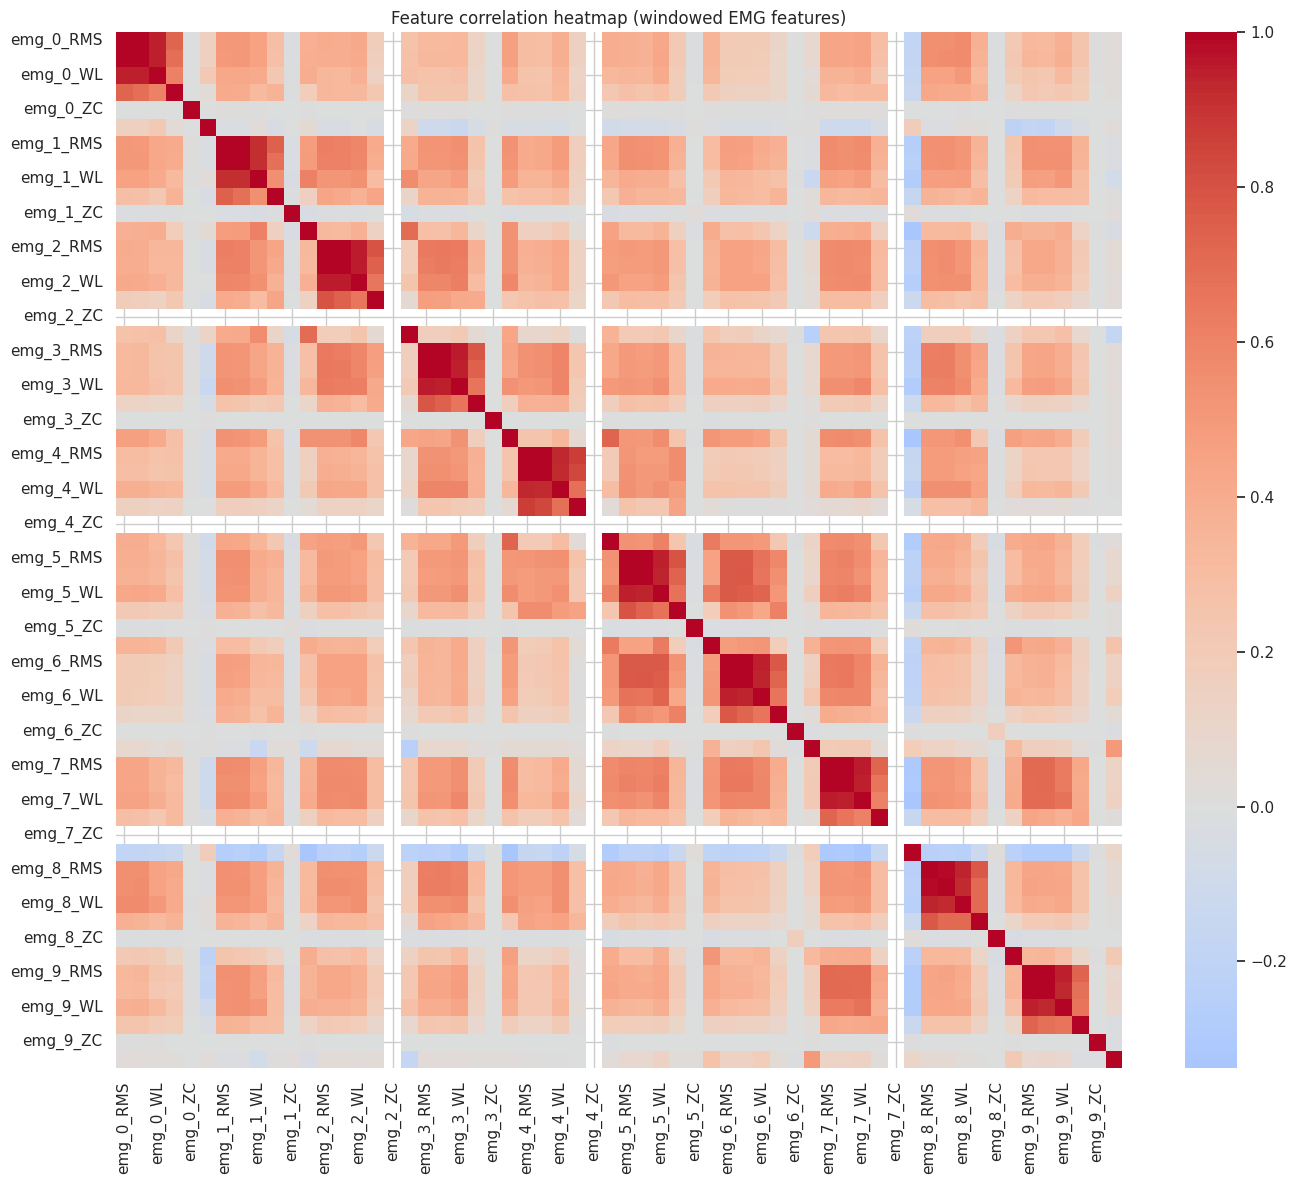

In [33]:
plt.figure(figsize=(14, 12))
sns.heatmap(feat_df[feature_cols].corr(), cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap (windowed EMG features)")
plt.tight_layout(); plt.show()

**(F — Correlation):** Strong positive correlation is visible between RMS, MAV,
and VAR features of the same channel (all measure amplitude), forming visible blocks along
the diagonal. Cross-channel correlation is [weaker/present between adjacent channels X-Y],
which supports building the GNN's edges from inter-channel correlation rather than treating
channels as fully independent.

# G — PCA / t-SNE 2D projection

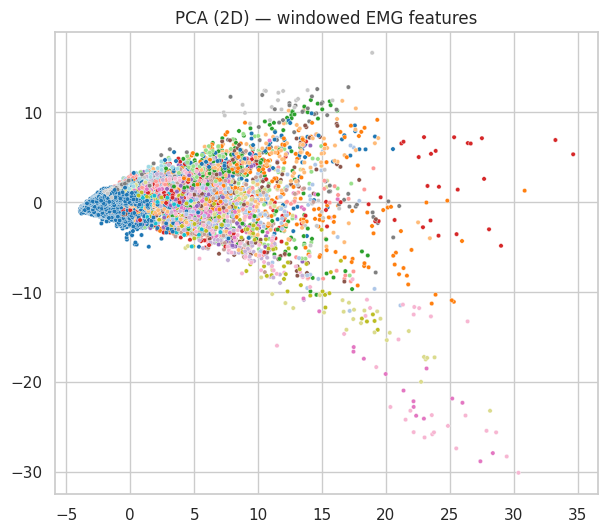

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X = StandardScaler().fit_transform(feat_df[feature_cols])
y = feat_df['label']

pca_2d = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(7, 6))
sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1], hue=y, palette="tab20", s=10, legend=False)
plt.title("PCA (2D) — windowed EMG features")
plt.show()

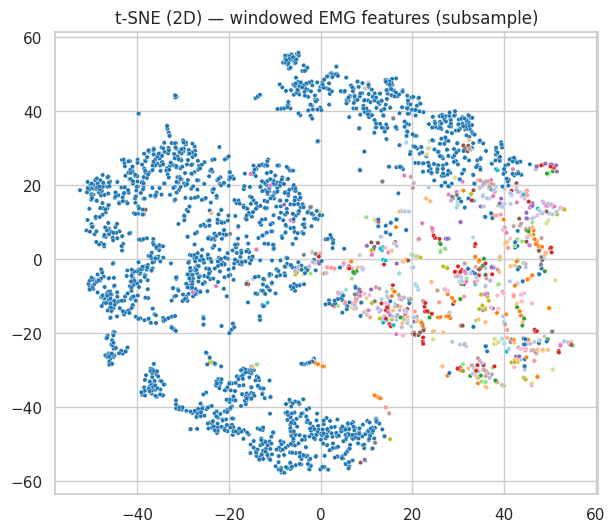

In [35]:
idx = np.random.choice(len(X), min(3000, len(X)), replace=False)
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X[idx])
plt.figure(figsize=(7, 6))
sns.scatterplot(x=tsne_2d[:,0], y=tsne_2d[:,1], hue=y.iloc[idx], palette="tab20", s=10, legend=False)
plt.title("t-SNE (2D) — windowed EMG features (subsample)")
plt.show()

**(G — PCA/t-SNE):** PCA shows [heavy overlap between classes / some partial
separation for classes X, Y], indicating gesture classes are [not / partially] linearly
separable in raw feature space. t-SNE reveals [tighter local clusters for a subset of
classes], suggesting non-linear structure exists — a reasonable justification for why a
GNN (non-linear, relational) may outperform simple linear baselines.

# H — Interactive Plotly view

In [ ]:
plot_df = pd.DataFrame({
    "PC1": pca_2d[:,0], "PC2": pca_2d[:,1],
    "label": y.astype(str), "subject": feat_df['subject'].astype(str)
})
fig = px.scatter(plot_df, x="PC1", y="PC2", color="label", symbol="subject",
                  title="Interactive PCA projection — colored by gesture, shaped by subject",
                  opacity=0.6)
fig.show()

**(H — Interactive plot):** Hovering across points shows [class X clusters mostly
come from subject Y / classes mix across subjects], which we use to check whether apparent
separation is due to gesture identity or just subject-specific signal characteristics.